# PDEformer Finetuning Demo: Raw vs Finetuned

This notebook compares the pretrained PDEformer-L checkpoint against the Burgers2D-viscous finetuned checkpoint. It has two parts:

1. logged metrics from the finetuning run, including the epoch-0 raw-model baseline;
2. a live side-by-side evaluation on held-out Burgers2D samples.

The default paths match the local run under `exp/finetune/burgers2d_viscous/model-L/2026-06-16-22-36-51`. Change the constants in the first code cell if you want to demo a different finetuned model.

In [1]:
from pathlib import Path
import copy
import csv
import gc

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import torch

from src import load_config, get_model
from src.core.metric import calculate_l2_error
from src.data import load_dataset, split_data_tuple
from src.torch_compat import context

CONFIG_PATH = Path("configs/finetune/burgers2d_viscous_model-L.yaml")
PRETRAINED_CKPT = Path("model-L.pt")
RUN_DIR = Path("exp/finetune/burgers2d_viscous/model-L/2026-06-16-22-36-51")
FINETUNED_CKPT = RUN_DIR / "ckpt/model_best.ckpt"
RESULT_CSV = RUN_DIR / "table/result.csv"

DEVICE_TARGET = "CPU"
MAX_EVAL_BATCHES = None  # set to an integer for a quicker smoke demo
PLOT_SAMPLE_INDEX = 0
PLOT_TIME_INDEX = -1

context.set_context(mode=context.PYNATIVE_MODE, device_target=DEVICE_TARGET)
for path in [CONFIG_PATH, PRETRAINED_CKPT, FINETUNED_CKPT, RESULT_CSV]:
    if not path.exists():
        raise FileNotFoundError(path)

print(f"Using config: {CONFIG_PATH}")
print(f"Raw checkpoint: {PRETRAINED_CKPT}")
print(f"Finetuned checkpoint: {FINETUNED_CKPT}")

Using config: configs/finetune/burgers2d_viscous_model-L.yaml
Raw checkpoint: model-L.pt
Finetuned checkpoint: exp/finetune/burgers2d_viscous/model-L/2026-06-16-22-36-51/ckpt/model_best.ckpt


## Logged Finetuning Curve

The training script evaluates before any updates at epoch 0, so the first point is the raw pretrained model. Later points show the finetuned model during training.

| epoch | test_l2_mean | test_l2_max | train_l2_mean |
| --- | --- | --- | --- |
| 0 | 0.267256 | 0.543832 | 0.25704 |
| 5 | 0.171196 | 0.386773 | 0.11507 |
| 10 | 0.160805 | 0.365923 | 0.0813198 |
| 15 | 0.157565 | 0.360755 | 0.066146 |
| 20 | 0.16127 | 0.351128 | 0.0678925 |

| model | epoch | test_l2_mean | relative_improvement |
| --- | --- | --- | --- |
| raw pretrained | 0 | 0.267256 | 0 |
| best finetuned | 15 | 0.157565 | 0.410433 |

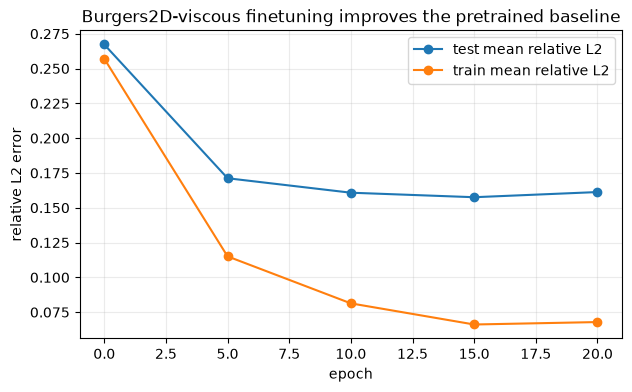

In [2]:
def read_metric_history(csv_path, metric_map):
    history_by_epoch = {}
    with open(csv_path, newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            for name, col in metric_map.items():
                step_col = f"{col} step"
                if row.get(col) and row.get(step_col):
                    epoch = float(row[step_col])
                    history_by_epoch.setdefault(epoch, {"epoch": epoch})[name] = float(row[col])
    return [history_by_epoch[key] for key in sorted(history_by_epoch)]


def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    sep = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = []
    for row in rows:
        values = []
        for col in columns:
            value = row.get(col, "")
            if isinstance(value, float):
                values.append(f"{value:.6g}")
            else:
                values.append(str(value))
        body.append("| " + " | ".join(values) + " |")
    return "\n".join([header, sep] + body)

metric_cols = {
    "test_l2_mean": "test_all_all/l2_error_mean",
    "test_l2_max": "test_all_all/l2_error_max",
    "train_l2_mean": "train_all_all/l2_error_mean",
}

history = read_metric_history(RESULT_CSV, metric_cols)
display(Markdown(markdown_table(history, ["epoch", "test_l2_mean", "test_l2_max", "train_l2_mean"])))

raw_logged = history[0]
best_logged = min(history, key=lambda row: row["test_l2_mean"])
summary = [
    {"model": "raw pretrained", "epoch": int(raw_logged["epoch"]), "test_l2_mean": raw_logged["test_l2_mean"], "relative_improvement": 0.0},
    {"model": "best finetuned", "epoch": int(best_logged["epoch"]), "test_l2_mean": best_logged["test_l2_mean"], "relative_improvement": 1 - best_logged["test_l2_mean"] / raw_logged["test_l2_mean"]},
]
display(Markdown(markdown_table(summary, ["model", "epoch", "test_l2_mean", "relative_improvement"])))

epochs = [row["epoch"] for row in history]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, [row["test_l2_mean"] for row in history], marker="o", label="test mean relative L2")
if all("train_l2_mean" in row for row in history):
    ax.plot(epochs, [row["train_l2_mean"] for row in history], marker="o", label="train mean relative L2")
ax.set_xlabel("epoch")
ax.set_ylabel("relative L2 error")
ax.set_title("Burgers2D-viscous finetuning improves the pretrained baseline")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Live Held-Out Evaluation

This section reloads the same test loader twice and scores the raw and finetuned checkpoints on identical samples.

In [ ]:
# Took 2m41s to run
def make_eval_config(checkpoint_path):
    cfg = load_config(str(CONFIG_PATH))
    cfg.model.load_ckpt = str(checkpoint_path)
    cfg.data.num_workers = 0
    cfg.eval.plot_num_per_type = 0
    return cfg


def get_test_items(config):
    dataset_train, data_updater, train_iter_dict, test_iter_dict = load_dataset(config)
    try:
        items = []
        for pde_type, datasets in test_iter_dict.items():
            for datafile, pair in datasets.items():
                dataset_iter, dataset = pair
                items.append((pde_type, datafile, dataset_iter, dataset))
        return items, data_updater
    except Exception:
        data_updater("terminate")
        raise


def evaluate_checkpoint(checkpoint_path, keep_sample=False):
    cfg = make_eval_config(checkpoint_path)
    test_items, data_updater = get_test_items(cfg)
    model = get_model(cfg)
    model.set_train(False)

    rows = []
    sample = None
    with torch.no_grad():
        for pde_type, datafile, dataset_iter, dataset in test_items:
            batch_count = 0
            iterator = dataset_iter.create_tuple_iterator() if hasattr(dataset_iter, "create_tuple_iterator") else dataset_iter
            for data_tuple in iterator:
                input_tuple, label, data_idx = split_data_tuple(data_tuple)
                pred = model(*input_tuple)
                l2 = calculate_l2_error(pred, label)
                for i, value in enumerate(l2):
                    rows.append({
                        "pde_type": pde_type,
                        "datafile": datafile,
                        "data_idx": int(data_idx[i]),
                        "relative_l2": float(value),
                    })
                if keep_sample and sample is None:
                    i = min(PLOT_SAMPLE_INDEX, label.shape[0] - 1)
                    sample = {
                        "pred": pred[i].asnumpy().astype(np.float32),
                        "label": label[i].asnumpy().astype(np.float32),
                        "coord": input_tuple[-1][i].asnumpy().astype(np.float32),
                        "data_idx": int(data_idx[i]),
                        "data_info": dataset.get_pde_info(int(data_idx[i])),
                    }
                batch_count += 1
                if MAX_EVAL_BATCHES is not None and batch_count >= MAX_EVAL_BATCHES:
                    break
    data_updater("terminate")
    del model
    gc.collect()
    return rows, sample

raw_scores, raw_sample = evaluate_checkpoint(PRETRAINED_CKPT, keep_sample=True)
finetuned_scores, finetuned_sample = evaluate_checkpoint(FINETUNED_CKPT, keep_sample=True)

def describe_scores(scores):
    arr = np.asarray([row["relative_l2"] for row in scores], dtype=np.float32)
    return {
        "count": int(arr.size),
        "mean": float(arr.mean()),
        "std": float(arr.std()),
        "min": float(arr.min()),
        "median": float(np.median(arr)),
        "max": float(arr.max()),
    }

raw_desc = describe_scores(raw_scores)
ft_desc = describe_scores(finetuned_scores)
score_rows = []
for metric in ["count", "mean", "std", "min", "median", "max"]:
    score_rows.append({"metric": metric, "raw pretrained": raw_desc[metric], "finetuned": ft_desc[metric]})
score_rows.append({
    "metric": "improvement_vs_raw",
    "raw pretrained": "",
    "finetuned": 1 - ft_desc["mean"] / raw_desc["mean"],
})
display(Markdown(markdown_table(score_rows, ["metric", "raw pretrained", "finetuned"])))

| metric | raw pretrained | finetuned |
| --- | --- | --- |
| count | 16 | 16 |
| mean | 0.267256 | 0.157565 |
| std | 0.0898145 | 0.0765652 |
| min | 0.162583 | 0.0906784 |
| median | 0.25114 | 0.123855 |
| max | 0.543831 | 0.360755 |
| improvement_vs_raw |  | 0.410433 |

## One-Sample Visual Comparison

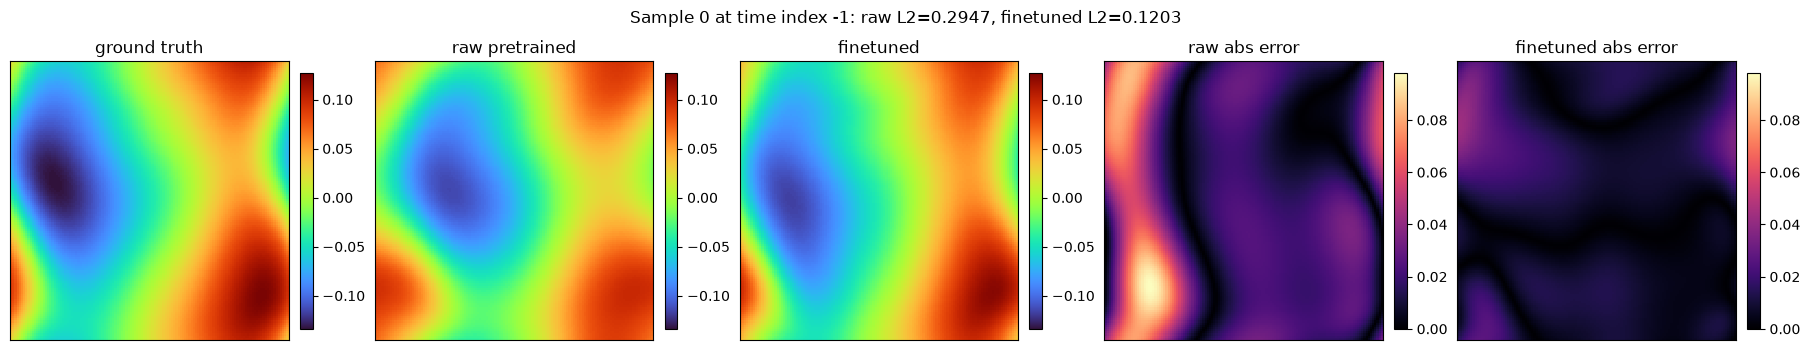

$u_t+uu_x+vu_y-\nu(u_{xx}+u_{yy})=0$
$v_t+uv_x+vv_y-\nu(v_{xx}+v_{yy})=0$


In [4]:
def reshape_sample(sample):
    info = sample["data_info"]
    n_vars = sample["label"].shape[-1]
    if "scatter_size" in info:
        raise ValueError("This visual helper expects Cartesian-grid samples, not scatter samples.")
    shape = (info["n_t_grid"], info["n_x_grid"], info["n_y_grid"], n_vars)
    label = sample["label"].reshape(shape)
    pred = sample["pred"].reshape(shape)
    coord = sample["coord"].reshape(shape[:-1] + (4,))
    return label, pred, coord, info

label, raw_pred, coord, info = reshape_sample(raw_sample)
_, ft_pred, _, _ = reshape_sample(finetuned_sample)

var_idx = 0
time_idx = PLOT_TIME_INDEX
x = coord[time_idx, :, :, 1]
y = coord[time_idx, :, :, 2]
truth = label[time_idx, :, :, var_idx]
raw = raw_pred[time_idx, :, :, var_idx]
ft = ft_pred[time_idx, :, :, var_idx]

fields = [truth, raw, ft, np.abs(raw - truth), np.abs(ft - truth)]
titles = ["ground truth", "raw pretrained", "finetuned", "raw abs error", "finetuned abs error"]

vmin = min(truth.min(), raw.min(), ft.min())
vmax = max(truth.max(), raw.max(), ft.max())
err_vmax = max(fields[3].max(), fields[4].max())

fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), constrained_layout=True)
for ax, field, title in zip(axes, fields, titles):
    if "error" in title:
        mesh = ax.pcolormesh(x, y, field, shading="auto", cmap="magma", vmin=0, vmax=err_vmax)
    else:
        mesh = ax.pcolormesh(x, y, field, shading="auto", cmap="turbo", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)

raw_l2 = calculate_l2_error(torch.as_tensor(raw_sample["pred"])[None], torch.as_tensor(raw_sample["label"])[None])[0]
ft_l2 = calculate_l2_error(torch.as_tensor(finetuned_sample["pred"])[None], torch.as_tensor(finetuned_sample["label"])[None])[0]
fig.suptitle(
    f"Sample {raw_sample['data_idx']} at time index {time_idx}: "
    f"raw L2={raw_l2:.4f}, finetuned L2={ft_l2:.4f}"
)
plt.show()

print(info.get("pde_latex", ""))

## Takeaway

Use the logged curve for a lightweight posted demo, and use the live evaluation cells when you want reproducible before/after numbers from the checkpoints themselves.